Prof. Guadalupe Pascal

Prof. Julián E. Tornillo

-----------------------------------------------
# Programación dinámica con OpenAI Gym

En este notebook se desarrolla un ejemplo que recorre los principales conceptos sobre los Procesos de Decisión de Markov (mdp) y Programación Dinámica para el Aprendizaje por Refuerzo.


Se continua el ejemplo del entorno ***Frozen Lake (o "Lago Congelado")***

https://gymnasium.farama.org/environments/toy_text/frozen_lake de la librería OpenAI Gym (https://gymnasium.farama.org/)

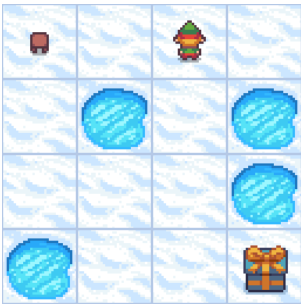

In [ ]:
# Modificación septiembre 2/2022
# Se requiere la versión 0.17.3 de OpenAI Gym para poder
# usar el método "render". Versiones más recientes no
# permiten usar este método desde Google Colab
!pip install gym==0.17.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.5 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=2e379764ee8f91f44ea89a06203a97c9d31e91fd65ba012b5d5f560c8ca8d7e7
  Stored in directory: /root/.cache/pip/wheels/99/7e/03/69cdeb432380e05bc9a56ff68451d8063e41aa06db508f4be5
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.1
    Uninstalling cloudpickle-3.1.1:
      Successfully uninstalled cloudpickle-3.1.1
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask 2025.5.0 requires cloudpickle>=

In [ ]:
# El entorno
import gym, numpy as np
env = gym.make('FrozenLake-v0')
env.render()


SFFF
FHFH
FFFH
HFFG


## POLÍTICA ALEATORIA INICIAL


Se define inicialmente una política aleatoria.

En este caso, la probabilidad no será de 0.33 como fue visto en clase, sino de 0.25 para cada una de las cuatro acciones.

In [ ]:
politica_aleatoria = np.ones([env.nS, env.nA]) / env.nA
print(politica_aleatoria.shape)
print('Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba')
print('-'*60)
print('Política aleatoria:')
print(politica_aleatoria)

(16, 4)
Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba
------------------------------------------------------------
Política aleatoria:
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


Haremos que el agente ejecute las acciones definidas por la Política.

Primero, evaluamos la política aleatoria definida inicialmente.

**¿Llega el agente a la meta?**

In [ ]:
s = env.reset()

for i in range(100):
    print(f'Time-step: {i+1}')
    a = np.argmax(politica_aleatoria[s]) #politica aleatoria
    s_, r, done, info = env.step(a)
    s = s_

    env.render()

    if done:
        if s==15:
            print('-----¡EL AGENTE LLEGÓ A LA META! :).....')
            print('Time steps:',i)

        else:
            print('-----El agente llegó a un estado terminal :(-----')
            print('Time steps:',i)
        break

    env.close()

Time-step: 1
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 2
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 3
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 4
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 5
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 6
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 7
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 8
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 9
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 10
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 11
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 12
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 13
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 14
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 15
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 16
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 17
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 18
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 19
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 20
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 21
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 22
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 23
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 24
  (Lef

## 2. Evaluación de la Política

Argumentos de entrada:
- El entorno
- La política π(s,a): arreglo Numpy de tamaño `nS x nA`. `politica[s][a]` indica la probabilidad de ejecutar la acción `a` partiendo del estado `s`
- `gamma`: el factor de descuento
- `theta`: criterio de convergencia del algoritmo

La función retornará `V`, un vector de `1xnS` con el valor de cada estado.

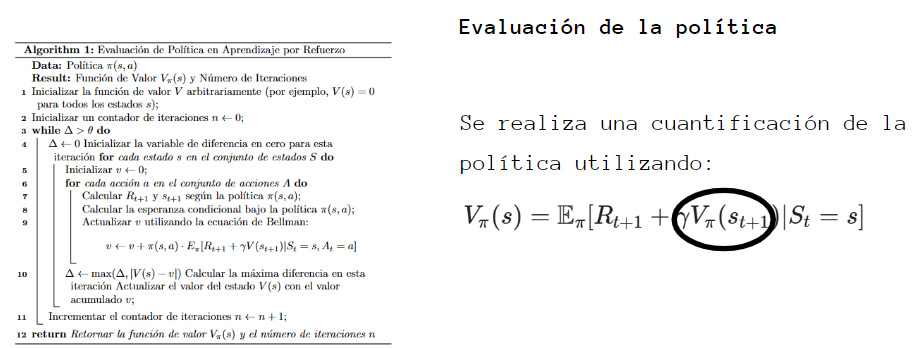

In [ ]:
# Constantes
GAMMA = 0.99
THETA = 1e-10

In [ ]:
def eval_politica(env,pol,gamma=GAMMA,theta=THETA):
    # Inicializar el vector con los valores de los estados
    V = np.zeros(env.nS)

    # Iterar y actualizar cada estado. Detener si delta < theta
    while True:
        delta = 0
        for s in range(env.nS):
            Vs = 0
            for a, pi in enumerate(pol[s]):
                for prob, s_, r, done in env.P[s][a]:
                    Vs += pi * prob * (r + gamma*V[s_])
            delta = max(delta, np.abs(V[s]-Vs))
            V[s] = Vs

        if delta < theta: # Si converge, detener las iteraciones
            break

    return V

Con esta función evaluamos la política aleatoria definida:

In [ ]:
V_aleatoria = eval_politica(env,politica_aleatoria)
print('Evaluación Política aleatoria:')
print(V_aleatoria.reshape((4,4)))

Evaluación Política aleatoria:
[[0.01235614 0.01042446 0.01933844 0.00947775]
 [0.01478705 0.         0.03889445 0.        ]
 [0.03260247 0.08433764 0.13781085 0.        ]
 [0.         0.17034482 0.43357944 0.        ]]


## 3. Mejora de la Política

Esta requiere el cálculo de la función Acción-Valor ($q_{\pi}(s,a)$): por cada estado indicará el valor de cada acción que se puede tomar:

Entonces, para un estado en particular, la función Q será un vector de `nA` elementos.

Implementaremos inicialmente esta función. Tendrá como argumentos de entrada:
- El entorno (`env`)
- El factor de descuento (`gamma`)
- La función estado-valor (`V`) obtenida anteriormente
- El estado sobre el que queremos calcular la función (`s`)

A la salida retornará el valor para cada acción:

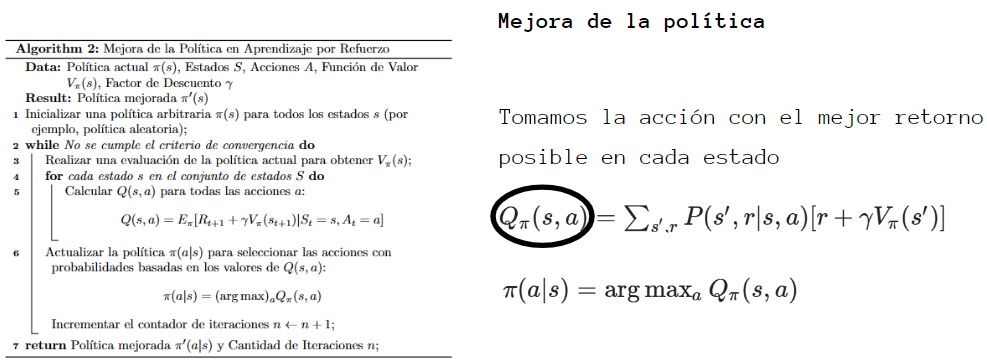

In [ ]:
def calcular_funcion_q(env, V, s, gamma=GAMMA):
    q = np.zeros(env.nA)
    for a in range(env.nA):
        for prob, s_, r, done in env.P[s][a]:
            q[a] += prob * (r + gamma * V[s_])
    return q

Probamos esta función calculándola para cada estado. Los valores Q quedarán almacenados en una matriz de `nSxnA`:

In [ ]:
Q_aleatoria = np.zeros([env.nS, env.nA])

for s in range(env.nS):
    Q_aleatoria[s] = calcular_funcion_q(env, V_aleatoria, s)

print('Función acción-valor Política Aleatoria')
print(Q_aleatoria)

Función acción-valor Política Aleatoria
[[0.01303478 0.01239732 0.01239732 0.01159512]
 [0.0075176  0.01045921 0.00982176 0.01389928]
 [0.02265692 0.0194029  0.02234451 0.01294941]
 [0.00950934 0.00950934 0.00625531 0.012637  ]
 [0.01971607 0.01563854 0.01483634 0.00895725]
 [0.         0.         0.         0.        ]
 [0.05185927 0.04547758 0.05185927 0.00638168]
 [0.         0.         0.         0.        ]
 [0.01563854 0.03859024 0.03271115 0.04346997]
 [0.06697261 0.11245019 0.10169137 0.0562364 ]
 [0.18374781 0.17091264 0.15591638 0.04066659]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.08404521 0.19929501 0.22712643 0.17091264]
 [0.24477259 0.53262834 0.52189213 0.43502471]
 [0.         0.         0.         0.        ]]


Con esta función lista, ya podemos implementar el algoritmo de Mejora de la Política.

Esta función tendrá como argumentos de entrada:
- El entorno (`env`)
- La función estado-valor (`V`) obtenida con la Evaluación de la Política (`evaluar_politica`)
- El factor de descuento (`gamma`)

A la salida la función retorna la política mejorada, una matriz de `nSxnA`:

In [ ]:
def mejorar_politica(env, V, gamma=GAMMA):

    # Partimos de una Política Arbitraria
    politica = np.zeros([env.nS, env.nA])

    # Y la mejoramos
    for s in range(env.nS):
        q = calcular_funcion_q(env, V, s, gamma)
        politica[s][np.argmax(q)] = 1

    return politica

Probamos la función con el entorno y la función estado-valor calculada anteriormente:

In [ ]:
politica_mejorada = mejorar_politica(env, V_aleatoria)
print('Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba')
print('-'*60)
print('Política aleatoria:')
print(politica_aleatoria)
print('Evaluación Política aleatoria:')
print(V_aleatoria.reshape((4,4)))

print('-'*60)

print('Evaluación de la Política:')
print(V_aleatoria.reshape((4,4)))

print('Política mejorada:')
print(politica_mejorada)
print('-'*60)

Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba
------------------------------------------------------------
Política aleatoria:
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Evaluación Política aleatoria:
[[0.01235614 0.01042446 0.01933844 0.00947775]
 [0.01478705 0.         0.03889445 0.        ]
 [0.03260247 0.08433764 0.13781085 0.        ]
 [0.         0.17034482 0.43357944 0.        ]]
------------------------------------------------------------
Evaluación de la Política:
[[0.01235614 0.01042446 0.01933844 0.00947775]
 [0.01478705 0.         0.03889445 0.        ]
 [0.03260247 0.08433764 0.13781085 0.        ]
 [0.         0.17034482 0.43357944 0.    

## 4. Iteración de la Política

Ahora aplicaremos de forma iterativa la evaluación y la mejora hasta que la Política ya no cambie, es decir hasta tener una Política Óptima.

La función aceptará estos argumentos de entrada:
- El entorno (`env`)
- El factor de descuento (`gamma`)
- El parámetro theta (`theta`)

Y entregará a la salida una Política Óptima (matriz de `nSxnA`). Además entregará la función valor (`V`) asociada a esa Política (que usaremos como referencia para ver el valor final de cada estado tras la convergencia)

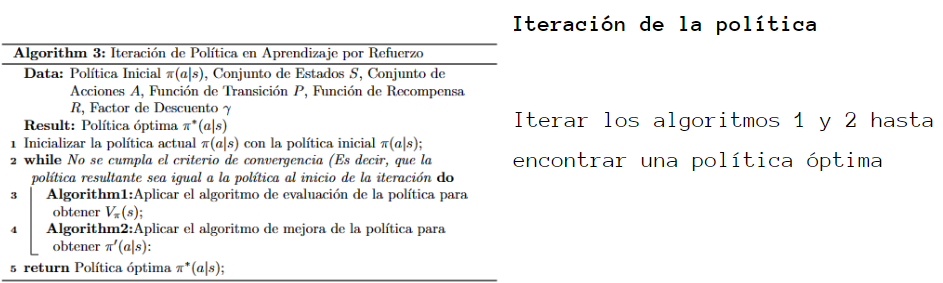

In [ ]:
def iterar_politica(env, gamma=GAMMA, theta=THETA):
    politica = np.ones([env.nS, env.nA]) / env.nA # Política arbitraria

    # Iterativamente Evaluar->Mejorar hasta que no haya cambios en la Política
    while True:
        V = eval_politica(env, politica)
        politica_nueva = mejorar_politica(env, V)

        if (politica_nueva == politica).all(): #all ya que compara elemento x elemento
            break

        politica = np.copy(politica_nueva)

    return politica_nueva, V #Comparar función estado-valor inicial y resultante

Y probamos esta función:

In [ ]:
politica_optima_ip, V_optima_ip = iterar_politica(env)

In [ ]:
print('Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba')
print('-'*60)

print('Política original (aleatoria):')
print(politica_aleatoria)
print('Función estado-valor original (política aleatoria):')
print(V_aleatoria.reshape((4,4)))

print('-'*60)

print('Política Óptima (Iteración de la Política):')
print(politica_optima_ip)
print('Función estado-valor (Iteración de la Política):')
print(V_optima_ip.reshape((4,4)))

print('-'*60)


Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba
------------------------------------------------------------
Política original (aleatoria):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Función estado-valor original (política aleatoria):
[[0.01235614 0.01042446 0.01933844 0.00947775]
 [0.01478705 0.         0.03889445 0.        ]
 [0.03260247 0.08433764 0.13781085 0.        ]
 [0.         0.17034482 0.43357944 0.        ]]
------------------------------------------------------------
Política Óptima (Iteración de la Política):
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.

## 5. Iteración de valores

En este caso la evaluación y la mejora se hacen de manera simultánea, en el mismo bloque de iteraciones.

Una vez ejecutado este bloque se tendrá la función estado-valor óptima, a partir de la cual se puede obtener una Política Óptima.

La función tendrá los mismos argumentos de entrada y de salida que la implementada en la Iteración de la Política:

- Entradas:
    - El entorno (`env`)
    - El factor de descuento (`gamma`)
    - El parámetro theta (`theta`)
- Salidas:
    - Una Política Óptima (matriz de `nSxnA`)
    - La función valor (`V`) asociada a esa Política (no es necesaria, pero la retornaremos para tenerla como referencia)


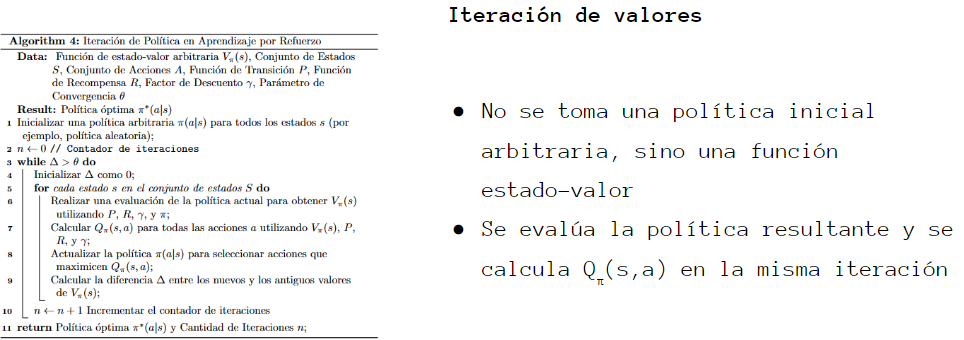

In [ ]:
def iteracion_valores(env, gamma=GAMMA, theta=THETA):
    V = np.zeros(env.nS)   # Función estado-valor arbitraria

    # Obtener función estado-valor óptima
    while True:
        delta = 0
        for s in range(env.nS):
            v = V[s]   # Almacenar el valor anterior
            V[s] = max(calcular_funcion_q(env, V, s))
            delta = max(delta,abs(V[s]-v))

        if delta < theta:
            break

    # Obtener política óptima a partir de la función estado-valor óptima
    politica = mejorar_politica(env, V)

    return politica, V

Evaluamos la función:

In [ ]:
politica_optima_iv, V_optima_iv = iteracion_valores(env)
print('Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba')
print('-'*60)
print('Política óptima (0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba')
print(politica_optima_iv)
print('Función estado-valor óptima:')
print(V_optima_iv.reshape((4,4)))
print('-'*60)

Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba
------------------------------------------------------------
Política óptima (0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]
Función estado-valor óptima:
[[0.54202593 0.49880319 0.47069569 0.4568517 ]
 [0.55845096 0.         0.35834807 0.        ]
 [0.59179874 0.64307982 0.61520756 0.        ]
 [0.         0.74172044 0.86283743 0.        ]]
------------------------------------------------------------


## 5. POLÍTICA ÓPTIMA

Ahora, evaluamos la política óptima obtenida según los parámetros indicados.

**¿Llega el agente a la meta?**

In [ ]:
s = env.reset()

for i in range(100):
    print(f'Time-step: {i+1}')
    a = np.argmax(politica_optima_iv[s]) #politica óptima (en este caso tomamos la política óptima calculada por iteración de valores)
    s_, r, done, info = env.step(a)
    s = s_

    env.render()

    if done:
        if s==15:
            print('-----¡EL AGENTE LLEGÓ A LA META! :).....')
            print('Time steps:',i)
        else:
            print('-----El agente llegó en un estado terminal :(-----')
            print('Time steps:',i)
        break




    env.close()

Time-step: 1
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 2
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 3
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 4
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 5
  (Up)
SFFF
FHFH
FFFH
HFFG
Time-step: 6
  (Up)
SFFF
FHFH
FFFH
HFFG
Time-step: 7
  (Down)
SFFF
FHFH
FFFH
HFFG
Time-step: 8
  (Left)
SFFF
FHFH
FFFH
HFFG
Time-step: 9
  (Left)
SFFF
FHFH
FFFH
HFFG
-----El agente llegó en un estado terminal :(-----
Time steps: 8
